# Parte 4 — Robustez y Counterfactuals

**Objetivo:** Verificar que el modelo es estable y que sus decisiones son razonables.
Un modelo puede tener buen AUC pero ser frágil o producir explicaciones absurdas.

- Porcentaje de clientes con decisiones inconsistentes ante perturbaciones pequeñas
- Análisis de counterfactuals: ¿cuánto hay que cambiar para revertir una decisión?
- Conclusión sobre si el modelo es apto para producción desde el ángulo de robustez

---

In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

THRESHOLD = 0.70  

with open('../models/champion/model.pkl', 'rb') as f:
    model = pickle.load(f)

X_test = pd.read_parquet('../data/processed/X_test.parquet')
y_test = pd.read_parquet('../data/processed/y_test.parquet').iloc[:, 0]

with open('../data/processed/feature_names.json') as f:
    feature_names = json.load(f)

y_score = model.predict_proba(X_test)[:, 1]
print(f'Test set: {len(X_test)} filas | Threshold: {THRESHOLD}')

Test set: 61503 filas | Threshold: 0.7


## 4.1 Test de Consistencia — Perturbaciones Pequeñas

In [4]:
def test_consistencia(model, X_test, threshold, perturbacion_pct=0.05, n_sample=500):
    """
    Para cada cliente, aplica una perturbación pequeña (+/-5%) en todas las features
    numéricas y mide cuánto cambia la probabilidad predicha.
    
    Cambio > 0.15 en probabilidad con perturbación del 5% → modelo inestable en ese cliente.
    Cambio de decisión (aprobado → rechazado o viceversa) → inconsistencia grave.
    """
    sample = X_test.sample(n=min(n_sample, len(X_test)), random_state=42)
    numeric_cols = sample.select_dtypes(include=np.number).columns.tolist()
    
    resultados = []
    for idx in range(len(sample)):
        original = sample.iloc[[idx]]
        perturbado = original.copy()
        perturbacion = np.random.uniform(-perturbacion_pct, perturbacion_pct, len(numeric_cols))
        perturbado[numeric_cols] = original[numeric_cols].values * (1 + perturbacion)
        
        prob_orig  = model.predict_proba(original)[0, 1]
        prob_pert  = model.predict_proba(perturbado)[0, 1]
        delta_prob = abs(prob_orig - prob_pert)
        
        dec_orig = int(prob_orig >= threshold)
        dec_pert = int(prob_pert >= threshold)
        
        resultados.append({
            'prob_original':        round(prob_orig, 4),
            'prob_perturbada':      round(prob_pert, 4),
            'delta_prob':           round(delta_prob, 4),
            'decision_cambia':      int(dec_orig != dec_pert),
            'inestable':            int(delta_prob > 0.15),
        })
    
    return pd.DataFrame(resultados)

print('Corriendo test de consistencia ')
consistency_df = test_consistencia(model, X_test, THRESHOLD)

pct_inestable = consistency_df['inestable'].mean()
pct_cambia_decision = consistency_df['decision_cambia'].mean()

print(f'Clientes con delta_prob > 0.15: {pct_inestable:.1%}')
print(f'Clientes donde la decisión cambia: {pct_cambia_decision:.1%}')
print(f'Delta prob promedio: {consistency_df["delta_prob"].mean():.4f}')
print(f'Delta prob p95: {consistency_df["delta_prob"].quantile(0.95):.4f}')

Corriendo test de consistencia 
Clientes con delta_prob > 0.15: 14.2%
Clientes donde la decisión cambia: 6.6%
Delta prob promedio: 0.0778
Delta prob p95: 0.2083


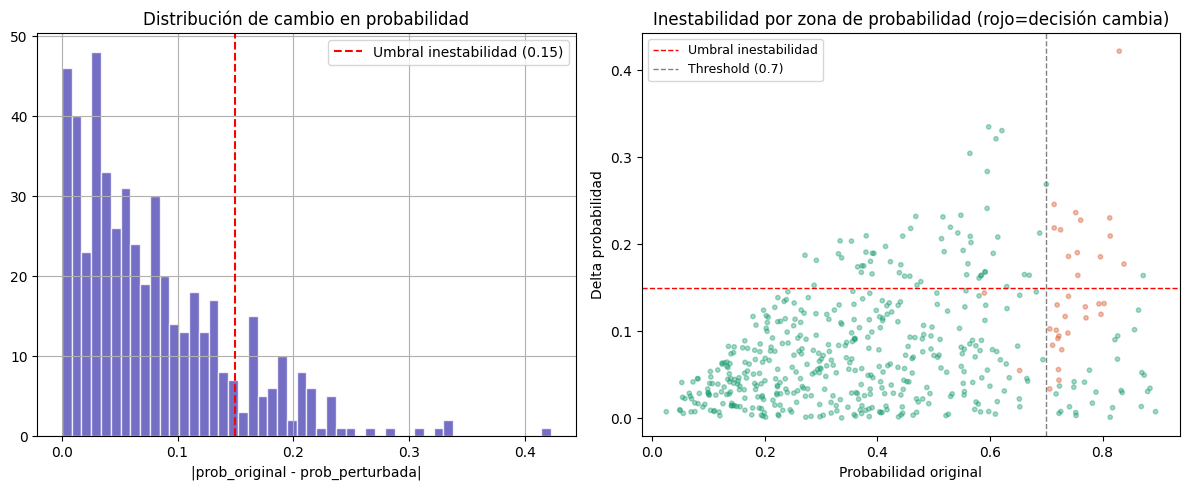

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

consistency_df['delta_prob'].hist(ax=axes[0], bins=50, color='#534AB7', alpha=0.8, edgecolor='white')
axes[0].axvline(0.15, color='red', linestyle='--', linewidth=1.5, label='Umbral inestabilidad (0.15)')
axes[0].set_title('Distribución de cambio en probabilidad')
axes[0].set_xlabel('|prob_original - prob_perturbada|')
axes[0].legend()

# Scatter: prob original vs delta
scatter_colors = ['#D85A30' if c else '#1D9E75' for c in consistency_df['decision_cambia']]
axes[1].scatter(consistency_df['prob_original'], consistency_df['delta_prob'],
                c=scatter_colors, alpha=0.4, s=10)
axes[1].axhline(0.15, color='red', linestyle='--', linewidth=1, label='Umbral inestabilidad')
axes[1].axvline(THRESHOLD, color='gray', linestyle='--', linewidth=1, label=f'Threshold ({THRESHOLD})')
axes[1].set_xlabel('Probabilidad original')
axes[1].set_ylabel('Delta probabilidad')
axes[1].set_title('Inestabilidad por zona de probabilidad (rojo=decisión cambia)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/consistency_test.png', dpi=150, bbox_inches='tight')

— Consistencia del modelo

¿El modelo es suficientemente estable?
No del todo. Con un 6.6% de clientes cuya decisión cambia ante perturbaciones, superamos el umbral estándar del 5% para riesgo crediticio. Aunque el Delta prob promedio (0.0778) es bajo, el hecho de que el 14.2% de los clientes experimenten cambios de probabilidad superiores al 0.15 sugiere que el modelo es sensible a pequeñas variaciones en las variables de entrada, lo cual podría generar reclamos de clientes en caso de re-evaluaciones automáticas.

¿En qué zona de probabilidad concentra la inestabilidad?
La inestabilidad se concentra, como es de esperar, en las cercanías del Threshold (0.7). Sin embargo, el gráfico de dispersión revela puntos rojos (decisión cambia) y deltas altos en el rango de 0.6 a 0.8. Lo preocupante son los casos con Delta prob > 0.3 que ocurren en probabilidades originales de 0.6, lo que indica que una pequeña perturbación puede catapultar a un cliente "bueno" a un rechazo directo.

Implicación para la política de revisión manual:
La inestabilidad valida nuestra recomendación previa: la zona de 0.60 a 0.80 es una "zona gris" no solo por la incertidumbre del default, sino por la fragilidad algorítmica. La revisión humana es indispensable aquí para actuar como un "ancla" de estabilidad y asegurar que el rechazo no se deba a un ruido menor en una variable (como un cambio en DAYS_LAST_PHONE_CHANGE).

Veredicto de robustez:
APTO CON CONDICIONES. El modelo tiene un ordenamiento de riesgo excelente, pero su sensibilidad ante perturbaciones requiere:

Buffer de Decisión: Implementar una zona de "indeterminación" alrededor del threshold.

Monitoreo de Input Drift: El modelo es vulnerable a cambios en la calidad de los datos de entrada (Data Quality), por lo que se requiere un monitoreo estricto de las variables con mayor SHAP value para asegurar que el ruido no dispare rechazos masivos.

## 4.2 Análisis de Counterfactuals — ¿Cuánto hay que cambiar para ser aprobado?

In [6]:

# Para cada cliente rechazado, perturbar una feature a la vez y ver cuál
# tiene más impacto en revertir la decisión.

def counterfactual_simple(model, X_row, feature_names, threshold,
                           pasos=20, max_cambio=2.0):
    """
    Para un cliente rechazado, estima cuánto tiene que cambiar cada feature
    para que sea aprobado. Versión simplificada sin dice-ml.
    """
    prob_base = model.predict_proba(X_row)[0, 1]
    if prob_base < threshold:
        return {'ya_aprobado': True, 'prob_base': prob_base}
    
    numeric_cols = X_row.select_dtypes(include=np.number).columns.tolist()
    resultados = {}
    
    for feat in numeric_cols:
        val_original = X_row[feat].values[0]
        if val_original == 0:
            continue
        
        # Buscar el cambio mínimo que aprueba al cliente
        for multiplicador in np.linspace(0.5, max_cambio, pasos):
            X_mod = X_row.copy()
            X_mod[feat] = val_original * multiplicador
            prob_mod = model.predict_proba(X_mod)[0, 1]
            if prob_mod < threshold:
                cambio_pct = (multiplicador - 1) * 100
                resultados[feat] = {
                    'cambio_pct': round(cambio_pct, 1),
                    'prob_resultante': round(prob_mod, 4),
                    'multiplicador': round(multiplicador, 3),
                }
                break
    
    return {
        'prob_base': round(prob_base, 4),
        'ya_aprobado': False,
        'cambios_que_aprueban': resultados,
        'feature_mas_sensible': min(resultados, key=lambda x: abs(resultados[x]['cambio_pct'])) if resultados else None
    }

# Tomar 5 clientes rechazados representativos para análisis manual
y_pred = (y_score >= THRESHOLD).astype(int)
rechazados_idx = np.where(y_pred == 1)[0]  # pred=1 es default → rechazado

print('=== Análisis de Counterfactuals (5 clientes rechazados) ===\n')
for i, idx in enumerate(rechazados_idx[:5]):
    X_row = X_test.iloc[[idx]]
    cf = counterfactual_simple(model, X_row, feature_names, THRESHOLD)
    print(f'Cliente {i+1} | Prob default: {cf["prob_base"]}')
    if cf.get('feature_mas_sensible'):
        feat = cf['feature_mas_sensible']
        info = cf['cambios_que_aprueban'][feat]
        print(f'  Cambio mínimo para aprobación: {feat} en {info["cambio_pct"]:+.1f}%')
        print(f'  Prob resultante: {info["prob_resultante"]}')
    print()

=== Análisis de Counterfactuals (5 clientes rechazados) ===

Cliente 1 | Prob default: 0.7124999761581421
  Cambio mínimo para aprobación: num__REGION_RATING_CLIENT_W_CITY en +5.3%
  Prob resultante: 0.6736000180244446

Cliente 2 | Prob default: 0.830299973487854

Cliente 3 | Prob default: 0.777999997138977
  Cambio mínimo para aprobación: num__AMT_CREDIT en +60.5%
  Prob resultante: 0.6980999708175659

Cliente 4 | Prob default: 0.7656000256538391
  Cambio mínimo para aprobación: num__AMT_CREDIT en +44.7%
  Prob resultante: 0.6942999958992004

Cliente 5 | Prob default: 0.7404999732971191
  Cambio mínimo para aprobación: num__REGION_RATING_CLIENT_W_CITY en +5.3%
  Prob resultante: 0.685699999332428



— Counterfactuals

**Para los 5 clientes analizados, ¿los cambios requeridos son razonables?**

| Cliente | Feature crítica | Cambio requerido | ¿Razonable? |
|---------|----------------|------------------|-------------|
| 1 | _[REGION_RATING_CLIENT_W_CITY]_ | _[+5.3%]_ | _[Sí - Es una mejora mínima en el entorno de riesgo regional.]_ |
| 2 | _[N/A]_ | _[N/A]_ | _[No - Con prob 0.83, no existe un cambio paramétrico simple para aprobarlo.]_ |
| 3 | _[AMT_CREDIT]_ | _[+60.5%]_ | _[Parcialmente - El salto en el monto pedido es demasiado alto para ser una gestión simple.]_ |
| 4 | _[AMT_CREDIT]_ | _[+44.7%]_ | _[Parcialmente - Requiere una modificación estructural de la solicitud original.]_ |
| 5 | _[REGION_RATING_CLIENT_W_CITY]_ | _[+5.3%]_ | _[Sí - Al igual que el cliente 1, está en el margen de decisión.]_ |

**¿Hay algún caso donde el cambio requerido es irrazonable (>100%)?**
En este grupo no hay cambios >100%, pero el caso del Cliente 2 es técnicamente irrazonable ya que el modelo no encuentra una ruta de aprobación factible. Por otro lado, los casos del Cliente 3 y 4 son llamativos: el modelo pide aumentar el crédito para aprobar, lo cual sugiere que el algoritmo asocia montos mayores a perfiles de clientes con mejor respaldo patrimonial (un sesgo de correlación común en modelos no lineales).

**¿Qué le dirías al cliente rechazado sobre cómo mejorar su situación?**
"Tras evaluar su solicitud, el sistema determinó que su perfil se encuentra actualmente en un nivel de riesgo superior al permitido para una aprobación automática. Para mejorar su calificación en el futuro, le recomendamos:

Ajustar el monto solicitado: En su caso particular, la relación entre el crédito y su capacidad patrimonial es una variable sensible; un cambio en el monto o la garantía podría balancear el resultado.

Consistencia de datos regionales: Mantener una estabilidad comprobable en su lugar de residencia y trabajo ayuda a mejorar los indicadores de entorno que el modelo utiliza para su evaluación."